In [2]:
import pandas as pd


In [3]:
df = pd.read_csv("../data/raw/Sleep_health_and_lifestyle_dataset.csv")

#entendimento dos dados -  data understanding

#quantas linhas existem?
#quantas colunas existem?
#quais sao os tipos de dados?
#existem dados faltando?
#como os dados estao distribuidos?

In [4]:
# estrutura geral

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
#as primeiras linhas

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [6]:
    #vendo as ultimas linhas

df.tail()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [7]:
#vendo os nomes das colunas

df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [8]:
#estatisticas gerais

df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [9]:
#vendo o formato do dataset

df.shape

(374, 13)

In [10]:
#ver valores nulos

df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [11]:
#MÓDULO 4- DATA CLEANING - LIMPEZA DE DADOS

df.duplicated().sum()

np.int64(0)

In [12]:
df["Sleep Disorder"].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [13]:
#confirmando quantas pessoas estao em cada grupo

df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [14]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")

In [15]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [16]:
df[["Blood Pressure"]].head()

,Blood Pressure
0,126/83
1,125/80
2,125/80
3,140/90
4,140/90


In [17]:
df[["Systolic", "Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True)

In [18]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [19]:
df["Systolic"] = df["Systolic"].astype(int)
df["Diastolic"] = df["Diastolic"].astype(int)

In [20]:
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
Systolic                     int64
Diastolic                    int64
dtype: object

In [21]:
df.drop("Blood Pressure", axis=1, inplace=True)

In [22]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Systolic', 'Diastolic'],
      dtype='object')

In [23]:
#MODULO 05-EDA AVANÇADA

df["Quality of Sleep"].value_counts()
#distribuimento da variavel principal



Quality of Sleep
8    109
6    105
7     77
9     71
5      7
4      5
Name: count, dtype: int64

In [24]:
df["Quality of Sleep"].mean()

np.float64(7.31283422459893)

Stress influencia na qualidade do sono?

In [25]:
df.groupby("Stress Level")["Quality of Sleep"].mean()

Stress Level
3    8.971831
4    7.671429
5    7.895522
6    7.000000
7    6.000000
8    5.857143
Name: Quality of Sleep, dtype: float64

Observa-se uma relação inversamente proporcional entre o nível de estresse e a qualidade do sono. Indivíduos com menor nível de estresse apresentam qualidade média de sono significativamente superior quando comparados àqueles com níveis elevados de estresse.

In [26]:
#ATIVIDADE FÍSICA MELHORA O SONO?

df.groupby("Physical Activity Level")["Quality of Sleep"].mean()

Physical Activity Level
30    7.352941
32    4.000000
35    5.000000
40    5.833333
42    6.000000
45    6.529412
47    6.000000
50    6.750000
55    7.333333
60    7.914286
65    7.000000
70    8.000000
75    8.014925
80    9.000000
85    9.000000
90    7.074627
Name: Quality of Sleep, dtype: float64

Observa-se uma tendência positiva entre nível de atividade física e qualidade do sono. Indivíduos com níveis moderados a elavados de atividade apresentam médias significativamente superiores de qualidade do sono quando comparados àqueles com baixa atividade física. 

In [27]:
#QUEM TEM DISTURBIO DO SONO REALMENTE DORME PIOR?

df.groupby("Sleep Disorder")["Quality of Sleep"].mean()

Sleep Disorder
Insomnia       6.532468
No Disorder    7.625571
Sleep Apnea    7.205128
Name: Quality of Sleep, dtype: float64

Existe impacto do distúrbio na qualidade do sono.
A insônia tem maior impacto negativo.
Apneia tem impacto moderado. Porém, a diferença não é grande. Isso indica que, o disturbio influencia,mas não é o único fator.

In [28]:
#PESSOAS COM DISTURBIO TEM MAIS STRESS

df.groupby("Sleep Disorder")["Stress Level"].mean()

Sleep Disorder
Insomnia       5.870130
No Disorder    5.114155
Sleep Apnea    5.666667
Name: Stress Level, dtype: float64

insomnia → maior stress → pior qualidade

Apneia → stress moderado → qualidade intermediária

Sem distúrbio → menor stress → melhor qualidade

Stress pode ser um fato associado à insônia 
E insônia impacta a qualidade do sono.

Pessoas diagnosticadas com insônia apresentam,média,níveis mais elevados de estresse quando comparadas aos demais grupos,reforçando a hipótese de que o estresse é um fator associado à pior qualidade do sono.

In [29]:
#PESSOAS COM APNEIA TEM PRESSAO MAIOR?

df.groupby("Sleep Disorder")[["Systolic", "Diastolic"]].mean()

,Systolic,Diastolic
Sleep Disorder,,
Insomnia,132.038961,86.857143
No Disorder,124.045662,81.000000
Sleep Apnea,137.769231,92.717949


In [30]:
#quem tem mais stress? homens ou mulheres?

df.groupby("Gender")["Stress Level"].mean()
#nao quer dizer que em geral é assim,mas que nesse dataset , esse padrao apareceu

Gender
Female    4.675676
Male      6.079365
Name: Stress Level, dtype: float64

In [31]:
#homens dormem pior do que mulheres?

df.groupby("Gender")["Quality of Sleep"].mean()

Gender
Female    7.664865
Male      6.968254
Name: Quality of Sleep, dtype: float64

# Visualização de dados


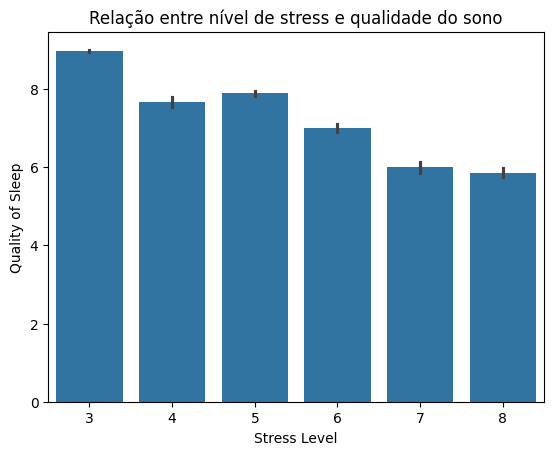

In [32]:
#STRESS VS QUALIDADE DE SONO

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Stress Level",y= "Quality of Sleep",data=df)
plt.title("Relação entre nível de stress e qualidade do sono")
plt.show()









SOBRE A 'QUEBRA' NO NIVEL 4 E 5

Stress 4-> qualidade menor que stress 5
isso parece estranho, mas é super normal em dados reais.

POR QUE ISSO ACONTECE?

MOTIVO 1: TAMANHO DA AMOSTRA
 - Tenha menos pessoas no nivel 4
 - ou perfil diferente nesse grupo

MOTIVO 2: VARIABILIDADE DOS DADOS

- Nem todo mundo com stress 5 é igual
- Nem todo mundo com stress 4 é igual

existem outros fatores influenciado:

- atividade fisica
- idade 
- profissao 
- saude

MOTIVO 3: MÉDIA NÃO É PERFEITA

VOCÊ ESTÁ VENDO MÉDIAS,E MEDIAS PODEM ESCONDER VARIAÇÕES INTERNAS.






# DISTRIBUIÇÃO DA QUALIDADE DO SONO POR GÊNERO



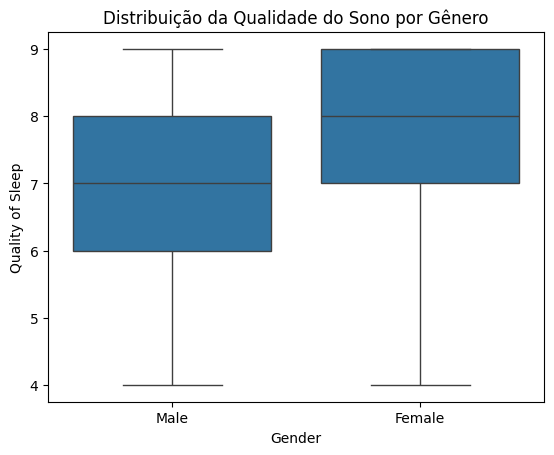

In [33]:
sns.boxplot(x="Gender", y="Quality of Sleep", data=df)
plt.title("Distribuição da Qualidade do Sono por Gênero")
plt.show()

Relação entre 3 variaveis ao mesmo tempo(Stress+ qualidade do sono+ genero)

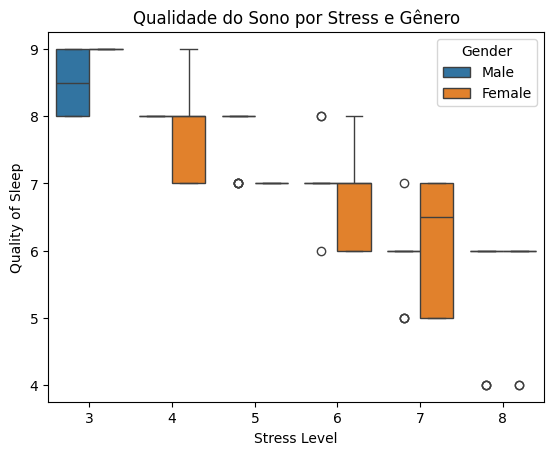

In [34]:
sns.boxplot(x="Stress Level", y="Quality of Sleep", hue="Gender", data=df)
plt.title("Qualidade do Sono por Stress e Gênero")
plt.show()

INSIGHT PROFISSIONAL DESSA TABELA:

O GENERO INFLUENCIA..

O STRESS INFLUENCIA MUITOS MAIS..

- A QUALIDADE DO SONO DIMINUI CONFORME O AUMENTO DO NÍVEL DE ESTRESSE PARA AMBOS OS GÊNEROS. EMBORA MULHERES APRESENTEM, EM GERAL, MELHORES NIVEIS DE SONO, ESSA DIFERENÇA NÃO É CONSISTENTE EM TODOS OS NÍVEIS DE ESTRESSE, INDICANDO QUE O ESTRESSE É O PRINCIPAL FATOR DETERMINANTE.


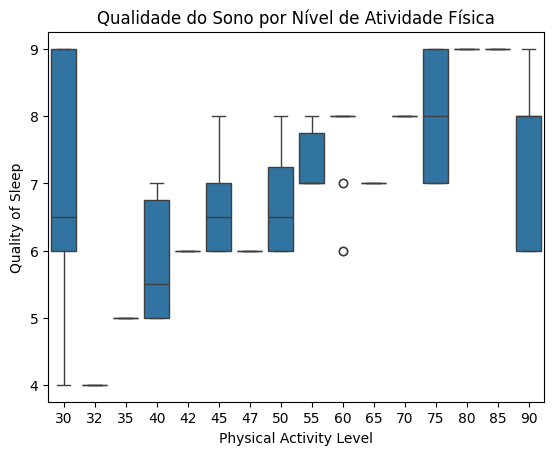

In [35]:
# RELAÇÃO ENTRE ATIVIDADE FÍSICA E SONO

sns.boxplot(x="Physical Activity Level", y="Quality of Sleep", data=df)
plt.title("Qualidade do Sono por Nível de Atividade Física")
plt.show()

- OBSERVA-SE UMA RELAÇÃO POSITIVA ENTRE O NÍVEL DE ATIVIDADE FÍSICA E A QUALIDADE DO SONO, ONDE INDIVÍDUOS MAIS ATIVOS TENDEM A APRESENTAR MELHORES PADRÕES DE SONO. ENTRETANTO, NÍVEIS EXTREMOS DE ATIVIDADE PODEM NÃO MANTER ESSE GANHO, INDICANDO POSSÍVEL EFEITO DE SATURAÇÃO.


# CONCLUSÃO E STORYTELLING

- A QUALIDADE DO SONO É DIRETAMENTE IMPACTADA POR FATORES COMO ESTRESSE E ATIVIDADE FÍSICA,SENDO O ESTRESSE O  PRINCIPAL FATOR NEGATIVO, ENQUANTO A ATIVIDADE FÍSICA ATUA COMO FATOR PROTETOR.

- O SONO NÃO É APENAS CONSEQUENCIA DO ESTILO DE VIDA - ELE É UM REFLEXO DIRETO DO EQUILIBRIO FÍSICO E MENTAL, SENDO FORTEMENTE PREJUDICADO PELO ESTRESSE E BENEFICIADO PELA ATIVIDADE FÍSICA.

-  INDIVÍDUOS COM DISTÚRBIOS DO SONO APRESENTAM PIORES INDICADORES DE SAÚDE.

- DIFERENÇAS DE GÊNERO FORAM OBSERVADAS,COM MULHERES APRESENTANDO MELHOR QUALIDADE DE SONO EM MÉDIA.

- OS DADOS INDICAM QUE MANTER NÍVEIS CONTROLADOS DE ESTRESSE E UMA ROTINA ATIVA SÃO FATORES ESSENCIAIS PARA UMA BOA QUALIDADE DO SONO.

- ALEM DISSO, DISTÚRBIOS COMO INSÔNIA E APNEIA DEMONSTRARAM IMPACTO SIGNIFICATIVO NÃO APENAS NO SONO,MAS TAMBÉM EM INDICADORES FISIOLÓGICOS, COMO PRESSAO ARTERIAL.

- PORTANTO, ESTRATÉGIAS VOLTADAS À REDUÇÃO DO ESTRESSE E INCENTIVO À ATIVIDADE FÍSICA PODEM CONTRIBUIR  DIRETAMENTE PARA A MELHORIA DA QUALIDADE DE VIDA.